In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans 
import csv 
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing

In [26]:
train = pd.read_csv('car_crash_train.csv', sep=',') 
test = pd.read_csv('car_crash_test.csv', sep=',')
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   str    
 3   Seatbelt Used              4000 non-null   str    
 4   Weather Conditions         4000 non-null   str    
 5   Road Conditions            4000 non-null   str    
 6   Crash Type                 4000 non-null   str    
 7   Vehicle Type               4000 non-null   str    
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   str    
 10  Tire Condition             4000 non-null   str    
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float64
 14  Dis

                                            Numerical 
Crash Speed (km/h)
Impact Angle (degrees)
Vehicle Age (years)
Driver Age
Driver Experience (years)
Alcohol Level (BAC%)
Visibility Distance (m)

                                            Categorical
Airbag Deployed
Seatbelt Used
Weather Conditions
Road Conditions
Crash Type
Vehicle Type
Brake Condition
Tire Condition
Distraction Level
Time of Day
Traffic Density
Severity

In [27]:
train.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


In [28]:
train.describe(include='object')

C:\Users\Alia\AppData\Local\Temp\ipykernel_25196\1464152888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include='object')


,Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Brake Condition,Tire Condition,Distraction Level,Time of Day,Traffic Density,Severity
count,4000,4000,4000,4000,4000,4000,4000,4000,1640,4000,4000,4000
unique,2,2,4,4,4,4,2,2,3,3,3,3
top,Yes,Yes,Clear,Dry,Side impact,Sedan,Good,Good,Phone,Afternoon,Medium,Minor Injury
freq,2817,3174,2345,2792,1413,1644,3369,3225,773,1579,1979,2756


In [29]:
for col in train.select_dtypes(include='object'):
    print(col, ":", train[col].unique())

Airbag Deployed : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Seatbelt Used : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Weather Conditions : <StringArray>
['Clear', 'Fog', 'Rain', 'Snow']
Length: 4, dtype: str
Road Conditions : <StringArray>
['Dry', 'Icy', 'Wet', 'Uneven']
Length: 4, dtype: str
Crash Type : <StringArray>
['Rollover', 'Head-on', 'Rear-end', 'Side impact']
Length: 4, dtype: str
Vehicle Type : <StringArray>
['Sedan', 'Truck', 'SUV', 'Motorcycle']
Length: 4, dtype: str
Brake Condition : <StringArray>
['Good', 'Worn out']
Length: 2, dtype: str
Tire Condition : <StringArray>
['Good', 'Worn out']
Length: 2, dtype: str
Distraction Level : <StringArray>
[nan, 'Phone', 'Other', 'Drowsiness']
Length: 4, dtype: str
Time of Day : <StringArray>
['Morning', 'Afternoon', 'Night']
Length: 3, dtype: str
Traffic Density : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Severity : <StringArray>
['Minor Injury', 'Severe Injury', 'Fatal']
Length: 3, dtype: str


C:\Users\Alia\AppData\Local\Temp\ipykernel_25196\3998115197.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(include='object'):


In [30]:
train['Distraction Level'].value_counts(dropna=False)

Distraction Level
NaN           2360
Phone          773
Drowsiness     439
Other          428
Name: count, dtype: int64

Missing values are actually meaningful in this feature due to majority so will just adjust it to another class.

In [31]:
train['Distraction Level'] = train['Distraction Level'].fillna('No Distraction')

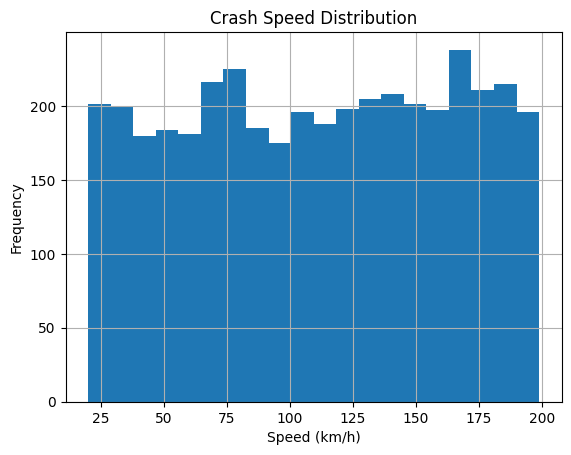

In [32]:
import matplotlib.pyplot as plt

df['Crash Speed (km/h)'].hist(bins=20)
plt.title("Crash Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.show()

It shows how are crash speeds distributed across the dataset? No major data quality issues in this feature

In [33]:
train.groupby('Severity')['Crash Speed (km/h)'].mean()

Severity
Fatal            116.951456
Minor Injury     110.584180
Severe Injury    110.921965
Name: Crash Speed (km/h), dtype: float64

Crash Speed alone is weakly predictive of Severity.

In [34]:
train.groupby(['Seatbelt Used', 'Severity']).size()

Seatbelt Used  Severity     
No             Fatal              44
               Minor Injury      560
               Severe Injury     222
Yes            Fatal             162
               Minor Injury     2196
               Severe Injury     816
dtype: int64

| Severity | No Seatbelt | Yes Seatbelt |
| -------- | ----------- | ------------ |
| Fatal    | 5.3%        | 5.1%         |
| Minor    | 67.8%       | 69.2%        |
| Severe   | 26.9%       | 25.7%        |
Seatbelt usage alone does not show a strong marginal effect on severity distribution. 

In [35]:
train.groupby(['Alcohol Level (BAC%)', 'Severity']).size()

Alcohol Level (BAC%)  Severity     
0.000054              Minor Injury     1
0.000098              Severe Injury    1
0.000303              Severe Injury    1
0.000312              Minor Injury     1
0.000424              Minor Injury     1
                                      ..
0.199713              Minor Injury     1
0.199759              Minor Injury     1
0.199776              Minor Injury     1
0.199895              Minor Injury     1
0.199936              Minor Injury     1
Length: 4000, dtype: int64

In [36]:
train.groupby(['Airbag Deployed', 'Severity']).size()

Airbag Deployed  Severity     
No               Fatal              63
                 Minor Injury      817
                 Severe Injury     303
Yes              Fatal             143
                 Minor Injury     1939
                 Severe Injury     735
dtype: int64

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score


# Split
X = train.drop("Severity", axis=1)
y = train["Severity"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Combine for encoding
combined = pd.concat([X, test], axis=0)
combined = pd.get_dummies(combined, drop_first=True)

X = combined.iloc[:len(X)]
test = combined.iloc[len(X):]

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling (IMPORTANT for KNN, Logistic Regression, Naive Bayes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test)

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_val_scaled)

print("Logistic Regression")
print(classification_report(y_val, pred_lr, zero_division=0))
print("F1:", f1_score(y_val, pred_lr, average="macro"))

Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      1.00      0.82       551
           2       0.00      0.00      0.00       208

    accuracy                           0.69       800
   macro avg       0.23      0.33      0.27       800
weighted avg       0.47      0.69      0.56       800

F1: 0.27189735998026154


In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_val_scaled)

print("KNN")
print(classification_report(y_val, pred_knn, zero_division=0))
print("F1:", f1_score(y_val, pred_knn, average="macro"))

KNN
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      0.93      0.79       551
           2       0.24      0.07      0.10       208

    accuracy                           0.66       800
   macro avg       0.31      0.33      0.30       800
weighted avg       0.54      0.66      0.57       800

F1: 0.2981141993560681


In [41]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_val)

print("Decision Tree")
print(classification_report(y_val, pred_dt, zero_division=0))
print("F1:", f1_score(y_val, pred_dt, average="macro"))

Decision Tree
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      0.89      0.78       551
           2       0.28      0.11      0.16       208

    accuracy                           0.64       800
   macro avg       0.32      0.33      0.31       800
weighted avg       0.55      0.64      0.58       800

F1: 0.31236723410446676


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

print("Random Forest")
print(classification_report(y_val, pred_rf, zero_division=0))
print("F1:", f1_score(y_val, pred_rf, average="macro"))

Random Forest
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      1.00      0.82       551
           2       0.00      0.00      0.00       208

    accuracy                           0.69       800
   macro avg       0.23      0.33      0.27       800
weighted avg       0.47      0.69      0.56       800

F1: 0.27189735998026154


In [43]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

pred_nb = nb.predict(X_val_scaled)

print("Naive Bayes")
print(classification_report(y_val, pred_nb, zero_division=0))
print("F1:", f1_score(y_val, pred_nb, average="macro"))

Naive Bayes
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      0.92      0.78       551
           2       0.29      0.06      0.10       208

    accuracy                           0.65       800
   macro avg       0.32      0.33      0.30       800
weighted avg       0.55      0.65      0.57       800

F1: 0.2956427630340674


In [44]:
results = {
    "Logistic Regression": f1_score(y_val, pred_lr, average="macro"),
    "KNN": f1_score(y_val, pred_knn, average="macro"),
    "Decision Tree": f1_score(y_val, pred_dt, average="macro"),
    "Random Forest": f1_score(y_val, pred_rf, average="macro"),
    "Naive Bayes": f1_score(y_val, pred_nb, average="macro"),
}

for k, v in results.items():
    print(k, ":", v)

Logistic Regression : 0.27189735998026154
KNN : 0.2981141993560681
Decision Tree : 0.31236723410446676
Random Forest : 0.27189735998026154
Naive Bayes : 0.2956427630340674


In [45]:
best_model = lr  # replace with your best model

best_model.fit(X, y)

final_preds = best_model.predict(test)

final_labels = le.inverse_transform(final_preds)

c:\Users\Alia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
submission = pd.DataFrame({
    "Severity": final_labels
})

submission.to_csv("submission.csv", index=False)

print("Submission ready!")

Submission ready!
